In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("predictive_maintenance.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
df = df.drop(columns=['UDI', 'product ID'], errors='ignore')

In [4]:
print("Data Shape:", df.shape)
df.head()

Data Shape: (10000, 9)


,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
print("---Missing Values ---")
print(df.isnull().sum())

---Missing Values ---
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [6]:
print("\n-- Duplicate Rows ---")
print("Total Duplicates:", df.duplicated().sum())


-- Duplicate Rows ---
Total Duplicates: 0


In [7]:
print("\n-- -Data Info---")
print(df.info())


-- -Data Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product ID               10000 non-null  object 
 1   Type                     10000 non-null  object 
 2   Air temperature [K]      10000 non-null  float64
 3   Process temperature [K]  10000 non-null  float64
 4   Rotational speed [rpm]   10000 non-null  int64  
 5   Torque [Nm]              10000 non-null  float64
 6   Tool wear [min]          10000 non-null  int64  
 7   Target                   10000 non-null  int64  
 8   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(3), object(3)
memory usage: 703.3+ KB
None


In [8]:
print(df.describe())

       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count         10000.000000             10000.000000            10000.000000   
mean            300.004930               310.005560             1538.776100   
std               2.000259                 1.483734              179.284096   
min             295.300000               305.700000             1168.000000   
25%             298.300000               308.800000             1423.000000   
50%             300.100000               310.100000             1503.000000   
75%             301.500000               311.100000             1612.000000   
max             304.500000               313.800000             2886.000000   

        Torque [Nm]  Tool wear [min]        Target  
count  10000.000000     10000.000000  10000.000000  
mean      39.986910       107.951000      0.033900  
std        9.968934        63.654147      0.180981  
min        3.800000         0.000000      0.000000  
25%       33.200000    

<Figure size 1200x800 with 0 Axes>

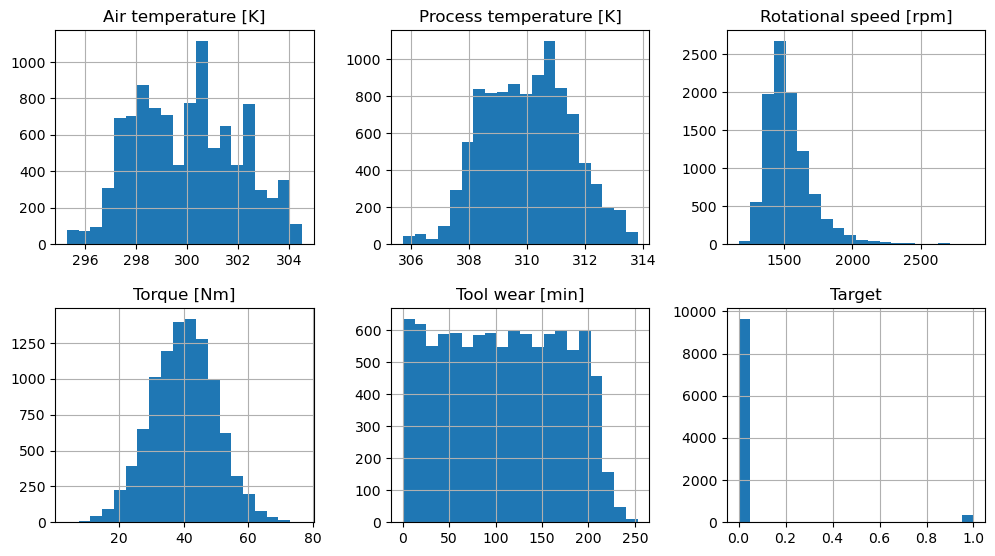

In [9]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 8))
df[numerical_cols].hist(bins=20, figsize=(12, 10), layout=(3, 3))
plt.show()

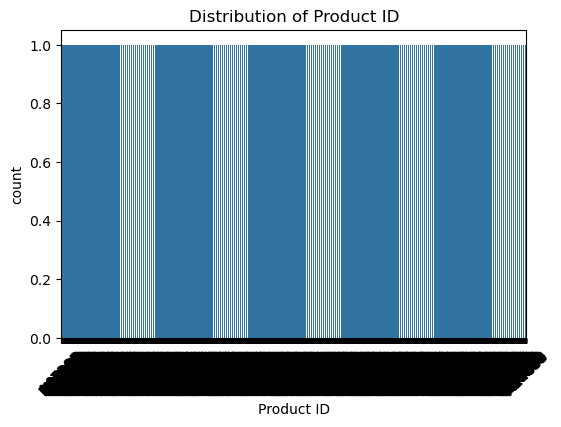

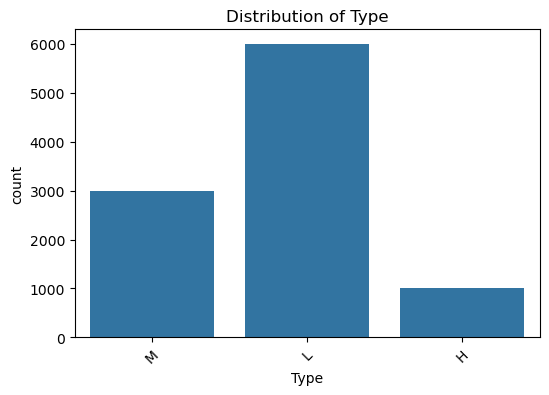

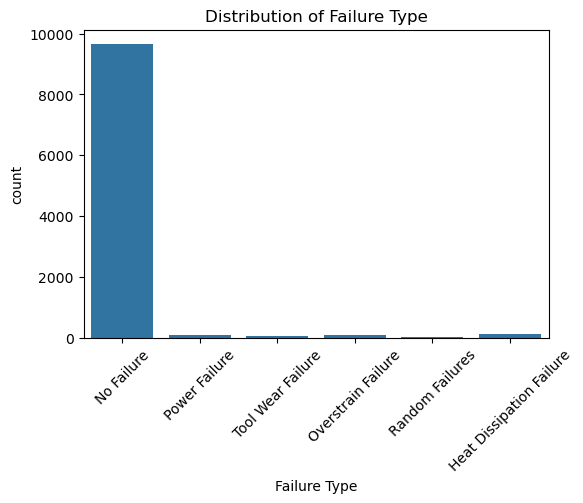

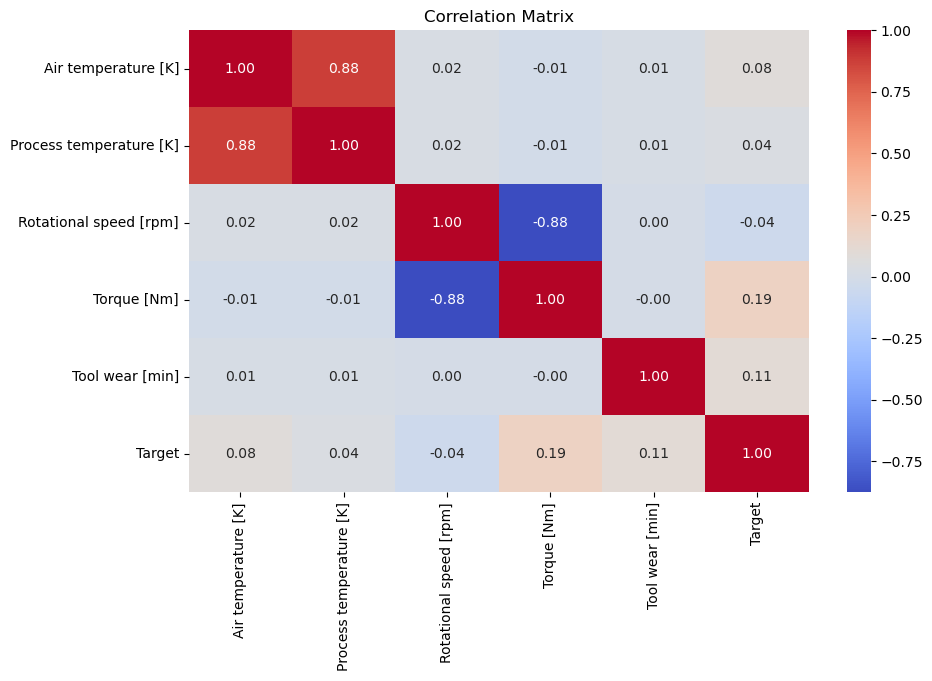

In [10]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

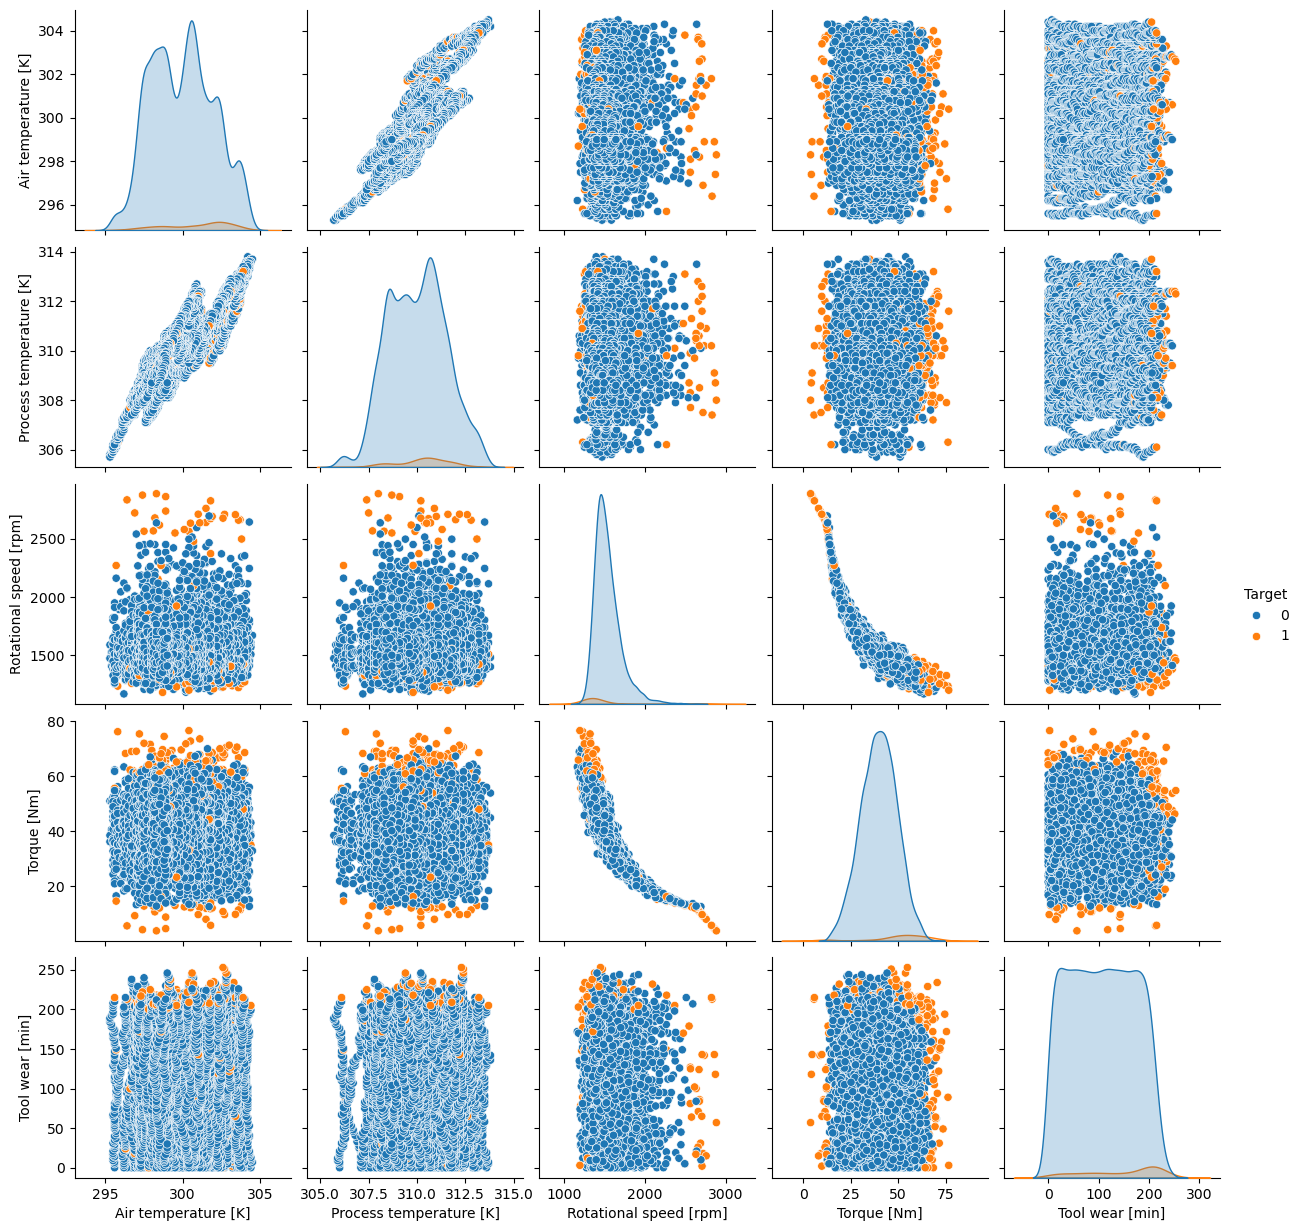

In [11]:
sns.pairplot(df[['Air temperature [K]', 'Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', "Target"]], hue = 'Target')

In [12]:
print("Taarget Distribution (Counts):")
print(df['Target'].value_counts())

print("\nTarget Distribution (percentage):")
print(df['Target'].value_counts(normalize=True) * 100)

Taarget Distribution (Counts):
Target
0    9661
1     339
Name: count, dtype: int64

Target Distribution (percentage):
Target
0    96.61
1     3.39
Name: proportion, dtype: float64


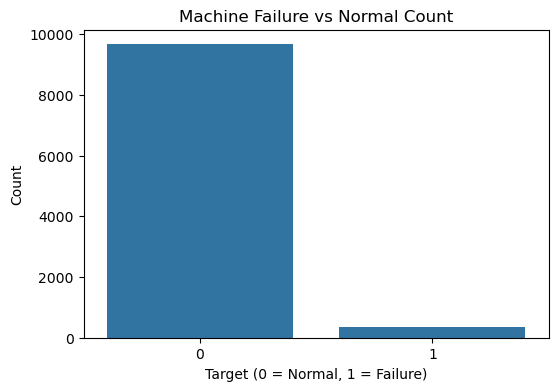

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Target')
plt.title('Machine Failure vs Normal Count')
plt.xlabel('Target (0 = Normal, 1 = Failure)')
plt.ylabel('Count')
plt.show()

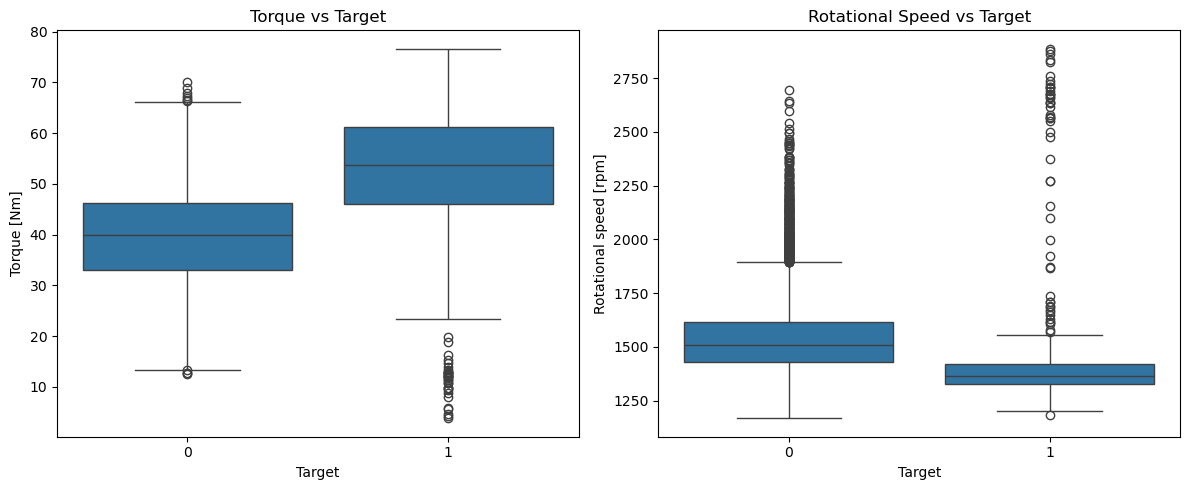

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Target', y='Torque [Nm]')
plt.title('Torque vs Target')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Target', y='Rotational speed [rpm]')
plt.title('Rotational Speed vs Target')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
df['Power'] = df['Torque [Nm]'] * (df['Rotational speed [rpm]'] * (2 * np.pi / 60))

if 'Type' in df.columns:
    type_dict = {'L': 0, 'M': 1, 'H': 2}
    df['Type_Encoded'] = df['Type'].map(type_dict)

In [16]:
X = df.drop(columns=['Target', 'Product ID', 'UDI', 'Type', 'Failure Type'], errors='ignore')

X = X.select_dtypes(include=['int64', 'float64'])
y = df['Target']

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Feature DataFrame 1st Row:")
print(X_scaled_df.head(1))

Scaled Feature DataFrame 1st Row:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0            -0.952389                 -0.94736                0.068185   

   Torque [Nm]  Tool wear [min]     Power  Type_Encoded  
0       0.2822        -1.695984  0.629443      0.744413  


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log)
print(f"\nLogistic Regression Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Training set shape: (8000, 7)
Testing set shape: (2000, 7)

Logistic Regression Accuracy: 96.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.57      0.18      0.27        68

    accuracy                           0.97      2000
   macro avg       0.77      0.59      0.63      2000
weighted avg       0.96      0.97      0.96      2000



In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("---Decision Tree Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

---Decision Tree Results ---
Accuracy: 97.90%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.69      0.71      0.70        68

    accuracy                           0.98      2000
   macro avg       0.84      0.85      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Results ---
Accuracy: 98.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.93      0.60      0.73        68

    accuracy                           0.98      2000
   macro avg       0.96      0.80      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("---Gradient Boosting Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

---Gradient Boosting Results ---
Accuracy: 98.95%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.76      0.83        68

    accuracy                           0.99      2000
   macro avg       0.95      0.88      0.91      2000
weighted avg       0.99      0.99      0.99      2000



In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import re

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean.columns = [re.sub(r'[\[\]<]', '', col) for col in X_train_clean.columns]
X_test_clean.columns = [re.sub(r'[\[\]<]', '', col) for col in X_test_clean.columns]

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_clean, y_train)

y_pred_xgb = xgb_model.predict(X_test_clean)

print("--- XGBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost Results ---
Accuracy: 98.85%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.72      0.81        68

    accuracy                           0.99      2000
   macro avg       0.96      0.86      0.90      2000
weighted avg       0.99      0.99      0.99      2000



In [23]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Target 1 count before SMOTE: {sum(y_train == 1)}")
print(f"Target 1 count after SMOTE: {sum(y_train_res == 1)}")

gb_smote = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_smote.fit(X_train_res, y_train_res)

y_pred_gb_smote = gb_smote.predict(X_test)

print("\n--- Gradient Boosting with SMOTE Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb_smote) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb_smote))

Target 1 count before SMOTE: 271
Target 1 count after SMOTE: 7729

--- Gradient Boosting with SMOTE Results ---
Accuracy: 93.60%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1932
           1       0.34      0.93      0.50        68

    accuracy                           0.94      2000
   macro avg       0.67      0.93      0.73      2000
weighted avg       0.97      0.94      0.95      2000



In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_cv_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

cv_scores = cross_val_score(gb_cv_model, X_scaled_df, y, cv=skf, scoring='roc_auc')

print("--- 5-Fold Cross Validation Results (ROC-AUC) ---")
print(f"Scores for each fold: {cv_scores}")
print(f"Mean ROC-AUC Score: {np.mean(cv_scores) * 100:.2f}%")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

--- 5-Fold Cross Validation Results (ROC-AUC) ---
Scores for each fold: [0.98464995 0.9825615  0.97211439 0.98172802 0.97325996]
Mean ROC-AUC Score: 97.89%
Standard Deviation: 0.0051


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_base = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)

print("--- Hyperparameter Tuning Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC Score: {grid_search.best_score_ * 100:.2f}%")

best_gb_model = grid_search.best_estimator_

--- Hyperparameter Tuning Results ---
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best ROC-AUC Score: 99.78%


Optimal Threshold: 0.9145
Best F1-Score at this Threshold: 0.7797


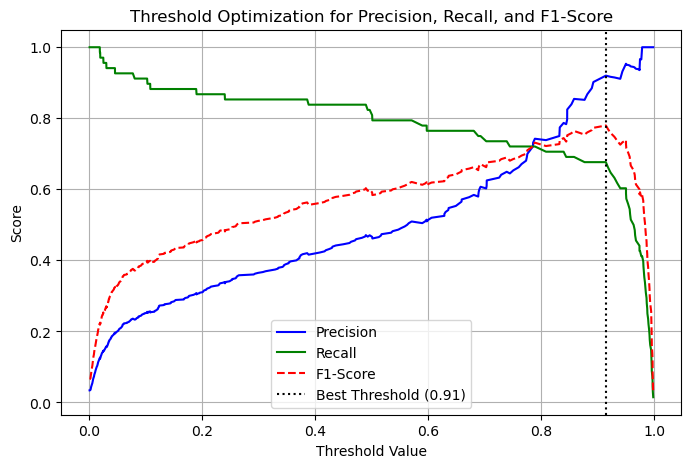

In [26]:
from sklearn.metrics import precision_recall_curve, f1_score

y_probs = best_gb_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1-Score at this Threshold: {f1_scores[best_idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='green')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='red', linestyle='--')
plt.axvline(best_threshold, color='black', linestyle=':', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Threshold Value')
plt.ylabel('Score')
plt.title('Threshold Optimization for Precision, Recall, and F1-Score')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

best_threshold = 0.7797
y_pred_optimal = (y_probs >= best_threshold).astype(int)

In [28]:
print("--- Final Model Evaluation (Threshold = 0.78) ---")
print(classification_report(y_test, y_pred_optimal))


--- Final Model Evaluation (Threshold = 0.78) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.72      0.72        68

    accuracy                           0.98      2000
   macro avg       0.85      0.86      0.85      2000
weighted avg       0.98      0.98      0.98      2000



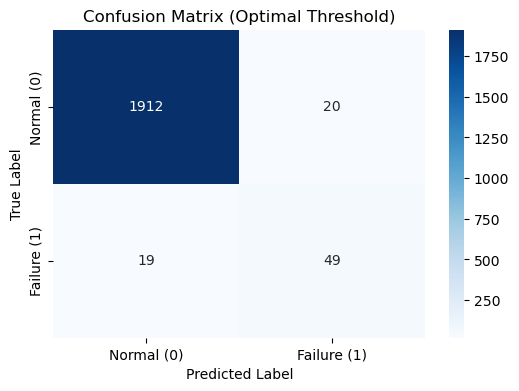

In [29]:
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Failure (1)'], 
            yticklabels=['Normal (0)', 'Failure (1)'])
plt.title('Confusion Matrix (Optimal Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

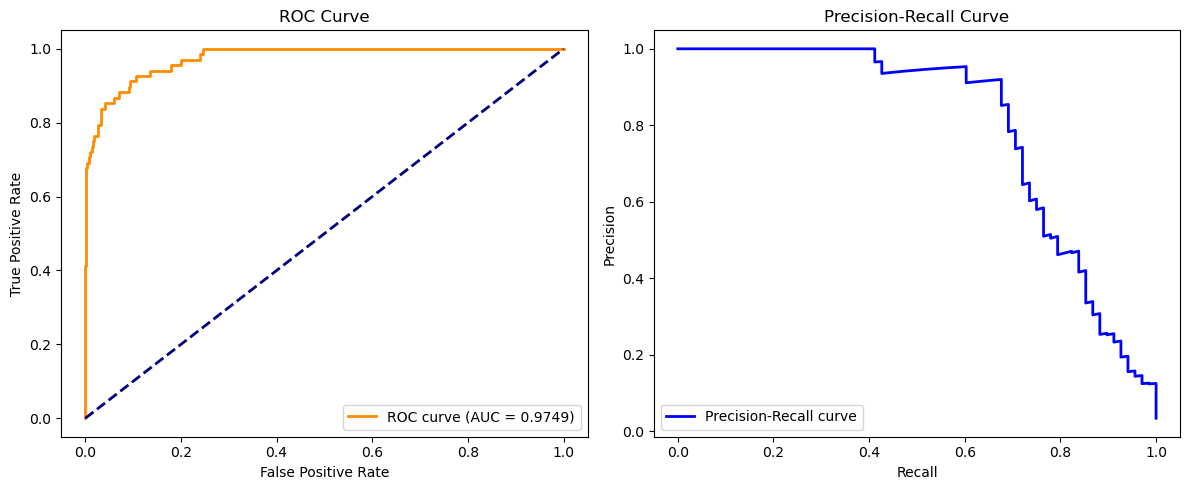

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

precisions, recalls, _ = precision_recall_curve(y_test, y_probs)
plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import classification_report

best_threshold = 0.7797
y_pred_optimal = (y_probs >= best_threshold).astype(int)

print("--- Final Model Evaluation (Threshold = 0.78) ---")
print(classification_report(y_test, y_pred_optimal))

--- Final Model Evaluation (Threshold = 0.78) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.72      0.72        68

    accuracy                           0.98      2000
   macro avg       0.85      0.86      0.85      2000
weighted avg       0.98      0.98      0.98      2000



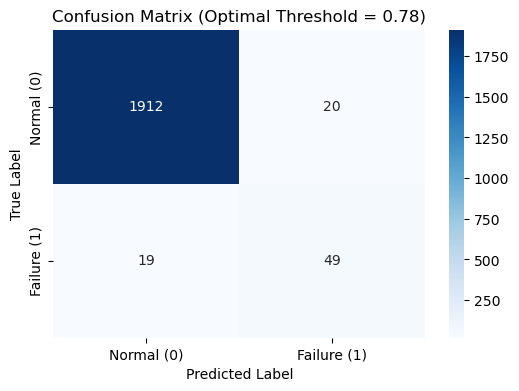

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Failure (1)'], 
            yticklabels=['Normal (0)', 'Failure (1)'])
plt.title('Confusion Matrix (Optimal Threshold = 0.78)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

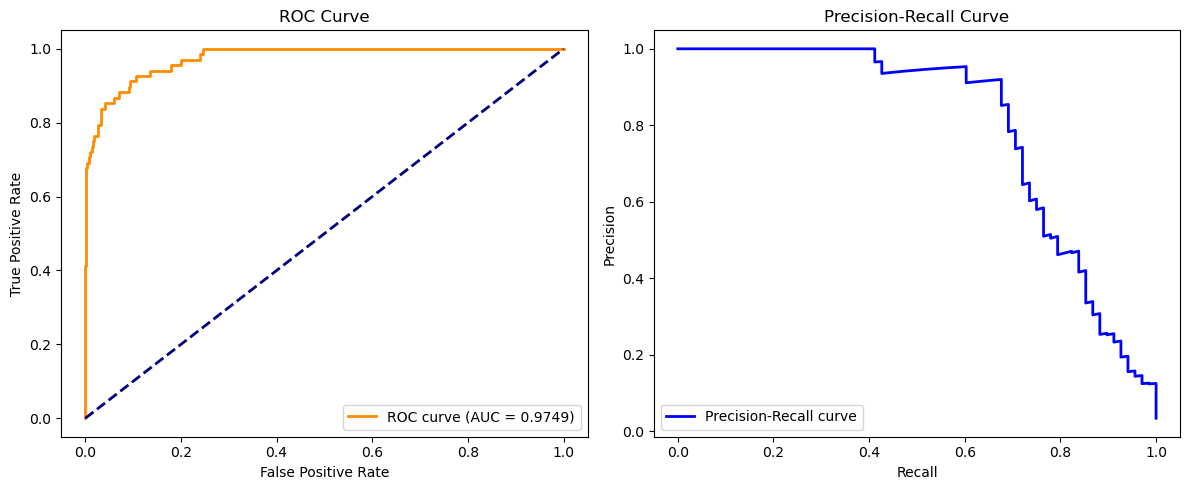

In [33]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

precisions, recalls, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

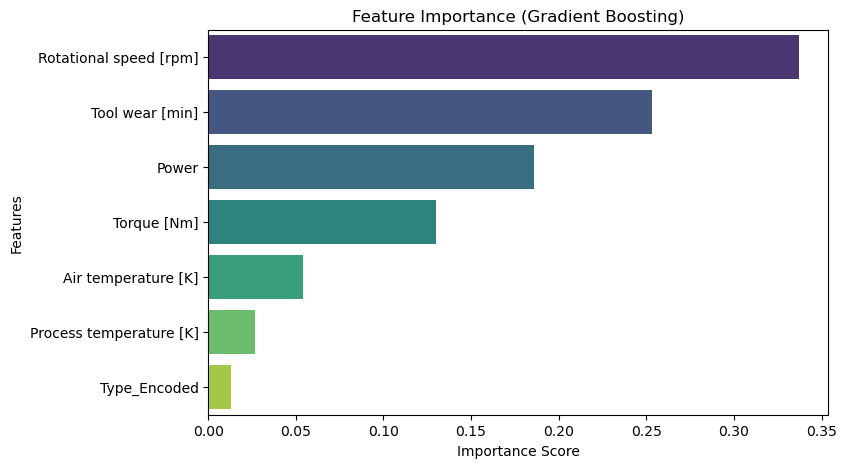

In [34]:
importances = best_gb_model.feature_importances_
feature_names = X_train.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (Gradient Boosting)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [35]:
import joblib

joblib.dump(best_gb_model, 'predictive_maintenance_gb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and Scaler saved successfully as .pkl files!")

Model and Scaler saved successfully as .pkl files!
